# Inspecting Model Output

In [64]:
from pathlib import Path
experiment_name = "OOA"
experiment_dir = Path(f"/sietch_colab/akapoor/XPopVAE/experiments/{experiment_name}")

## Trees Sequences


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tskit

In [66]:
sim_number = 0 
rep_number = 0

In [67]:
sim_basedir = Path(f'{experiment_dir}/simulations/{sim_number}/rep{rep_number}')

In [68]:
ts = tskit.load(f'{sim_basedir}/tree_sequence.trees')

### Inspecting ts output

In [69]:
ts

In [70]:
print("num_individuals:", ts.num_individuals)
print("num_samples:",     ts.num_samples)
print("num_sites:",       ts.num_sites)
print("nodes per ind:",   len(ts.individual(0).nodes))
print("geno_np shape:",   ts.genotype_matrix().shape)
print("geno_np max:",     ts.genotype_matrix().max())

num_individuals: 2000
num_samples: 4000
num_sites: 23833
nodes per ind: 2
geno_np shape: (23833, 4000)
geno_np max: 2


In [ ]:
# ── build biallelic diploid matrix ─────────────────────────────────────────────
G = ts.genotype_matrix()                                     # (sites, haplotypes)
print("raw unique values:", np.unique(G))
print("triallelic calls: ", (G == 2).sum())

biallelic_site_ids = np.array([v.site.id for v in ts.variants() if len(v.alleles) == 2])
hap = G[biallelic_site_ids, :]                               # (biallelic_sites, haplotypes)
print(f"sites after biallelic filter: {len(biallelic_site_ids)}")

# ── MAF filter ─────────────────────────────────────────────────────────────────
maf_threshold = 0.01
allele_freqs  = hap.mean(axis=1)
maf           = np.minimum(allele_freqs, 1 - allele_freqs)
maf_mask      = maf >= maf_threshold

hap                = hap[maf_mask, :]
biallelic_site_ids = biallelic_site_ids[maf_mask]
print(f"sites after MAF filter:       {len(biallelic_site_ids)}")

# ── diploid ────────────────────────────────────────────────────────────────────
dosage  = hap[:, 0::2] + hap[:, 1::2]                       # (biallelic_sites, individuals)
diploid = dosage.T                                           # (individuals, biallelic_sites)

print("hap unique:    ", np.unique(hap))
print("diploid shape: ", diploid.shape)
print("diploid unique:", np.unique(diploid))

raw unique values: [0 1 2]
triallelic calls:  4882


In [ ]:
# ── population metadata ────────────────────────────────────────────────────────
pop_id_to_name   = {pop.id: pop.metadata["name"] for pop in ts.populations()}
ind_id_to_pop    = {ind.id: pop_id_to_name[ind.population] for ind in ts.individuals()}

In [ ]:
# ── train/val/test split ───────────────────────────────────────────────────────
# train_discovery : 80% CEU
# validation_discovery: 20% CEU
# train_target    : 50% YRI
# test_target     : 50% YRI
rng = np.random.default_rng(seed=42)

train_discovery_inds, validation_discovery_inds = [], []
train_target_inds,    test_target_inds          = [], []

for ind_id, pop in ind_id_to_pop.items():
    if pop == "CEU":
        (train_discovery_inds if rng.random() < 0.8 else validation_discovery_inds).append(ind_id)
    elif pop == "YRI":
        (test_target_inds if rng.random() < 0.5 else train_target_inds).append(ind_id)

train_discovery_inds      = np.array(train_discovery_inds)
validation_discovery_inds = np.array(validation_discovery_inds)
train_target_inds         = np.array(train_target_inds)
test_target_inds          = np.array(test_target_inds)

print(f"train_discovery:      {len(train_discovery_inds)}")
print(f"validation_discovery: {len(validation_discovery_inds)}")
print(f"train_target:         {len(train_target_inds)}")
print(f"test_target:          {len(test_target_inds)}")

train_discovery_diploid      = diploid[train_discovery_inds, :]
validation_discovery_diploid = diploid[validation_discovery_inds, :]
train_target_diploid         = diploid[train_target_inds, :]
test_target_diploid          = diploid[test_target_inds, :]


In [ ]:
import tstrait

In [ ]:
# ── train/val/test windows (all sites) ────────────────────────────────────────
train_discovery_window      = train_discovery_diploid
validation_discovery_window = validation_discovery_diploid
train_target_window         = train_target_diploid
test_target_window          = test_target_diploid

# ── phenotype simulation ───────────────────────────────────────────────────────
model    = tstrait.trait_model(distribution="normal", mean=0, var=1)
num_causal = 100
rng_causal = np.random.default_rng(seed=42)
causal_site_ids = rng_causal.choice(biallelic_site_ids, size=num_causal, replace=False).tolist()

trait_df = tstrait.sim_trait(ts,
                             causal_sites=causal_site_ids,
                             model=model, alpha=0, random_seed=42)

In [ ]:
trait_df

In [ ]:
# ts, model, *, num_causal=None, causal_sites=None, alpha=None, h2=None, random_seed=None
phenotype_df = tstrait.sim_phenotype(ts, model = model, causal_sites = causal_site_ids, alpha = None, h2 = 1.0, random_seed=42)

In [ ]:
pheno = phenotype_df.phenotype

train_discovery_pheno      = pheno[pheno['individual_id'].isin(train_discovery_inds)]
validation_discovery_pheno = pheno[pheno['individual_id'].isin(validation_discovery_inds)]
train_target_pheno         = pheno[pheno['individual_id'].isin(train_target_inds)]
test_target_pheno          = pheno[pheno['individual_id'].isin(test_target_inds)]

In [ ]:
plt.figure()
plt.hist(train_discovery_pheno['phenotype'], bins=50, alpha=0.5, label='train_discovery')
plt.hist(validation_discovery_pheno['phenotype'], bins=50, alpha=0.5, label='validation_discovery')
plt.hist(train_target_pheno['phenotype'], bins=50, alpha=0.5, label='train_target')
plt.hist(test_target_pheno['phenotype'], bins=50, alpha=0.5, label='test_target')
plt.legend()
plt.title("Phenotype Distributions")
plt.xlabel("Phenotype Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# FST between CEU and YRI
pop_name_to_id = {pop.metadata["name"]: pop.id for pop in ts.populations()}

ceu_samples = ts.samples(population=pop_name_to_id["CEU"])
yri_samples = ts.samples(population=pop_name_to_id["YRI"])

fst = ts.Fst([ceu_samples, yri_samples])
print(f"FST (CEU vs YRI): {fst:.4f}")

## Doing a very straightforward GWAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import statsmodels.api as sm

BASE = '/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0'


In [2]:
# ── load data ─────────────────────────────────────────────────────────────────
discovery_train_geno  = np.load(f'{BASE}/genotype_matrices/discovery_train.npy')
discovery_train_pheno = np.load(f'{BASE}/phenotypes/discovery_train_pheno.npy')
biallelic_site_ids    = np.load(f'{BASE}/biallelic_site_ids.npy')

print(f'geno shape : {discovery_train_geno.shape}')
print(f'pheno shape: {discovery_train_pheno.shape}')

geno shape : (788, 4912)
pheno shape: (788,)


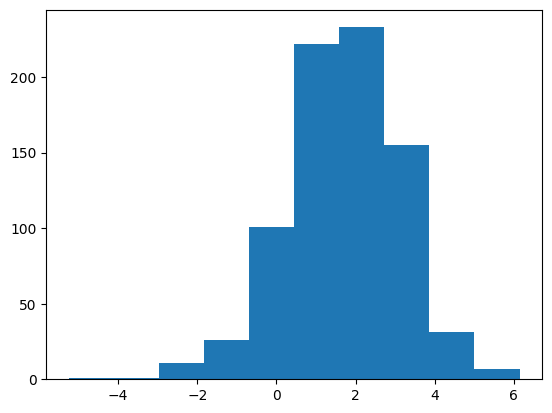

In [6]:
plt.figure()
plt.hist(discovery_train_pheno)
plt.show()

In [7]:
target_held_out_pheno = np.load(f'{BASE}/phenotypes/target_held_out_pheno.npy')

In [9]:
print(f'Mean: {target_held_out_pheno.mean():.4f}, Std: {target_held_out_pheno.std():.4f}')

Mean: 0.5751, Std: 2.2583


In [10]:
print(f'Mean: {discovery_train_pheno.mean():.4f}, Std: {discovery_train_pheno.std():.4f}')

Mean: 1.6601, Std: 1.4166


In [3]:
with open(f'{BASE}/trait_df.pkl', 'rb') as f:
    trait_df = pickle.load(f)

# ── check monomorphic sites ───────────────────────────────────────────────────
frac_mono = np.sum(discovery_train_geno.var(axis=0) == 0) / discovery_train_geno.shape[1]
print(f'Fraction of Monomorphic Sites: {frac_mono:.4f}')

# ── compute MAF per site in discovery_train ───────────────────────────────────
allele_freq = discovery_train_geno.mean(axis=0) / 2  # divide by 2 since diploid
mafs        = np.minimum(allele_freq, 1 - allele_freq)

# ── build geno dataframe with tskit site_ids as column names ─────────────────
# biallelic_site_ids[i] is the tskit site_id for column i of the geno matrix
geno_df           = pd.DataFrame(discovery_train_geno, columns=biallelic_site_ids)
pheno_series      = pd.Series(discovery_train_pheno)


Fraction of Monomorphic Sites: 0.0000


/tmp/ipykernel_3464003/2486900785.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trait_df = pickle.load(f)


In [4]:
trait_df

,position,site_id,effect_size,causal_allele,allele_freq,trait_id
0,7270,175,0.750451,C,0.02425,0
1,22880,541,0.940565,A,0.00025,0
2,30606,734,-1.951035,C,0.03450,0
3,34226,827,-1.302180,G,0.00025,0
4,36657,886,0.127840,C,0.00050,0
...,...,...,...,...,...,...
195,970874,23069,-0.394605,G,0.00050,0
196,983041,23362,-0.005122,C,0.00025,0
197,991788,23601,-0.163443,C,0.00025,0
198,994954,23700,0.337575,G,0.03200,0


In [5]:
trait_df['trait_id']

0      0
1      0
2      0
3      0
4      0
      ..
195    0
196    0
197    0
198    0
199    0
Name: trait_id, Length: 200, dtype: int64

In [6]:
# ── run GWAS ──────────────────────────────────────────────────────────────────
def run_gwas(geno_df, pheno_series):
    results = []
    for site_id in geno_df.columns:
        X     = sm.add_constant(geno_df[site_id])
        model = sm.OLS(pheno_series, X).fit()
        results.append({
            'site_id': site_id,
            'beta':    model.params[site_id],
            'se':      model.bse[site_id],
            'pvalue':  model.pvalues[site_id],
        })
    return pd.DataFrame(results)

gwas_results = run_gwas(geno_df, pheno_series)

# ── add MAF and true effect sizes ─────────────────────────────────────────────
gwas_results['maf']       = mafs
gwas_results['true_beta'] = gwas_results['site_id'].map(
    trait_df.set_index('site_id')['effect_size']
).fillna(0)  # non-causal sites get true beta = 0

Causal rare sites   : 16
Causal common sites : 19


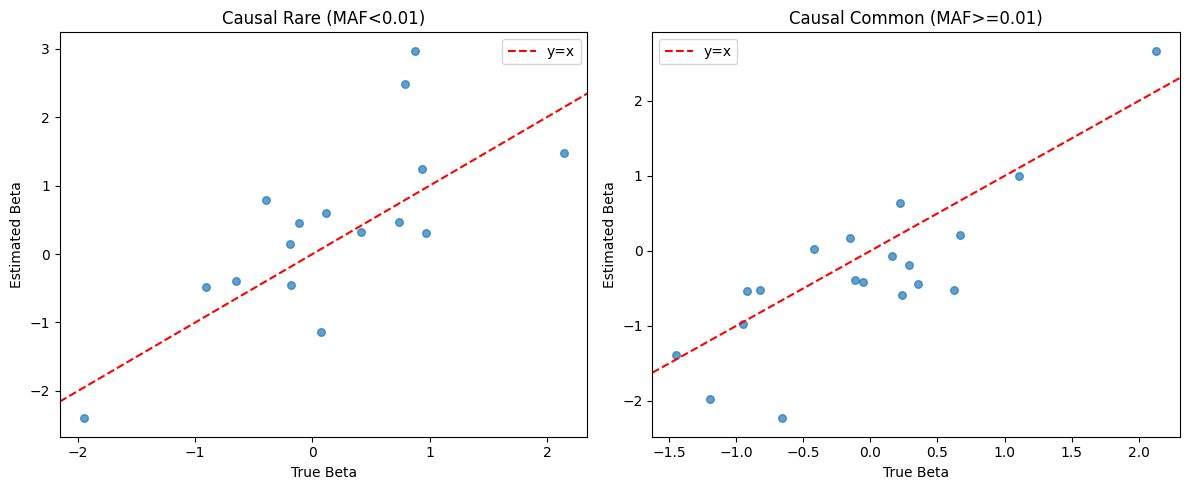

In [7]:
# ── stratify by MAF ───────────────────────────────────────────────────────────
# only look at causal sites
MAF_filter = 0.01
causal_gwas = gwas_results[gwas_results['true_beta'] != 0]
rare_causal   = causal_gwas[causal_gwas['maf'] <  MAF_filter]
common_causal = causal_gwas[causal_gwas['maf'] >= MAF_filter]

print(f'Causal rare sites   : {len(rare_causal)}')
print(f'Causal common sites : {len(common_causal)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, label in zip(axes, [rare_causal, common_causal], [f'Causal Rare (MAF<{MAF_filter})', f'Causal Common (MAF>={MAF_filter})']):
    ax.scatter(df['true_beta'], df['beta'], alpha=0.7, s=30)
    ax.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x')
    ax.set_xlabel('True Beta')
    ax.set_ylabel('Estimated Beta')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.savefig('gwas_beta_comparison_causal_only.png', dpi=150)
plt.show()

In [8]:
trait_df['maf'] = np.minimum(trait_df['allele_freq'], 1 - trait_df['allele_freq'])
trait_df['h2_contribution'] = 2 * trait_df['maf'] * (1 - trait_df['maf']) * trait_df['effect_size']**2
trait_df['h2_contribution'] /= trait_df['h2_contribution'].sum()

lost = trait_df[trait_df['maf'] < MAF_filter]
kept = trait_df[trait_df['maf'] >= MAF_filter]
print(f"Heritability in lost SNPs : {lost['h2_contribution'].sum():.1%}")
print(f"Heritability in kept SNPs : {kept['h2_contribution'].sum():.1%}")

Heritability in lost SNPs : 14.6%
Heritability in kept SNPs : 85.4%


In [9]:
# rough power calculation for each SNP
trait_df['h2_per_snp'] = 2 * trait_df['maf'] * (1-trait_df['maf']) * trait_df['effect_size']**2
trait_df['h2_per_snp'] /= trait_df['h2_per_snp'].sum()
print(trait_df[trait_df['maf'] >= 0.05]['h2_per_snp'].describe())

count    15.000000
mean      0.043420
std       0.043299
min       0.000027
25%       0.006901
50%       0.020526
75%       0.081429
max       0.126794
Name: h2_per_snp, dtype: float64


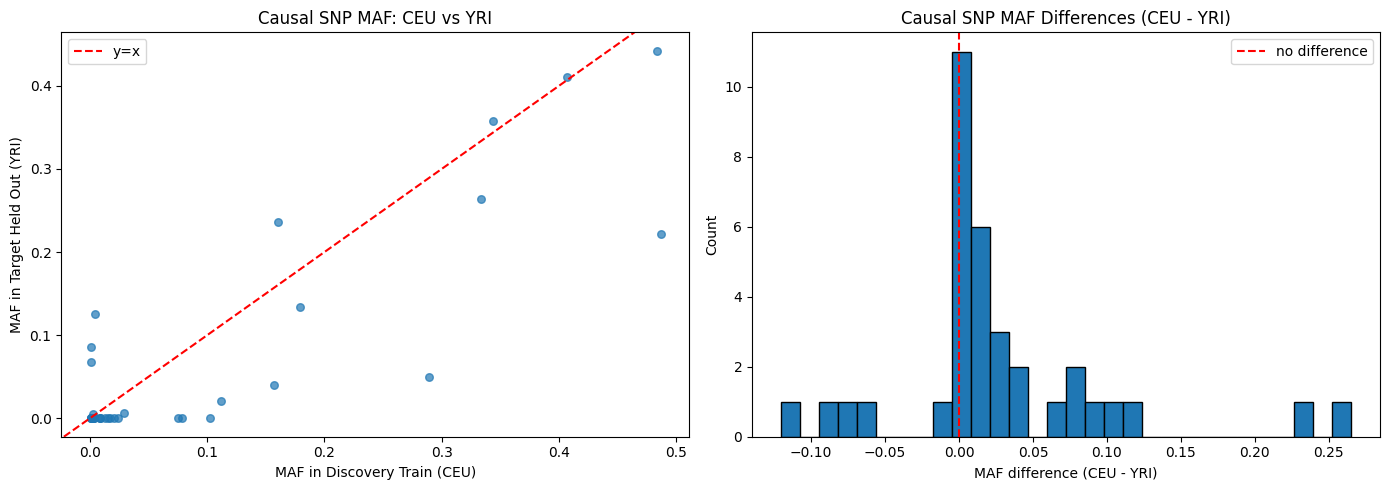


Causal SNP MAF difference summary (CEU - YRI):
count    35.000000
mean      0.026134
std       0.074930
min      -0.120716
25%       0.001269
50%       0.008249
75%       0.043485
max       0.265291
Name: maf_diff, dtype: float64


In [10]:
# ── load target held out ──────────────────────────────────────────────────────
target_held_out_geno = np.load(f'{BASE}/genotype_matrices/target_held_out.npy')

# ── compute MAF in each split ─────────────────────────────────────────────────
disc_allele_freq   = discovery_train_geno.mean(axis=0) / 2
target_allele_freq = target_held_out_geno.mean(axis=0) / 2

disc_maf   = np.minimum(disc_allele_freq,   1 - disc_allele_freq)
target_maf = np.minimum(target_allele_freq, 1 - target_allele_freq)

# ── build a dataframe of MAF per site ─────────────────────────────────────────
maf_df = pd.DataFrame({
    'site_id':    biallelic_site_ids,
    'maf_disc':   disc_maf,
    'maf_target': target_maf,
})

# ── filter to causal SNPs only ────────────────────────────────────────────────
causal_site_ids = trait_df['site_id'].values
causal_maf_df   = maf_df[maf_df['site_id'].isin(causal_site_ids)].copy()
causal_maf_df['maf_diff'] = causal_maf_df['maf_disc'] - causal_maf_df['maf_target']

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter: disc MAF vs target MAF per causal SNP
axes[0].scatter(causal_maf_df['maf_disc'], causal_maf_df['maf_target'], alpha=0.7, s=30)
axes[0].axline((0, 0), slope=1, color='red', linestyle='--', label='y=x')
axes[0].set_xlabel('MAF in Discovery Train (CEU)')
axes[0].set_ylabel('MAF in Target Held Out (YRI)')
axes[0].set_title('Causal SNP MAF: CEU vs YRI')
axes[0].legend()

# histogram of MAF differences
axes[1].hist(causal_maf_df['maf_diff'], bins=30, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', label='no difference')
axes[1].set_xlabel('MAF difference (CEU - YRI)')
axes[1].set_ylabel('Count')
axes[1].set_title('Causal SNP MAF Differences (CEU - YRI)')
axes[1].legend()

plt.tight_layout()
plt.savefig('causal_snp_maf_differences.png', dpi=150)
plt.show()

print(f"\nCausal SNP MAF difference summary (CEU - YRI):")
print(causal_maf_df['maf_diff'].describe())

## Taking a look at the matrices

In [61]:
discovery_train_geno.shape

(788, 4912)

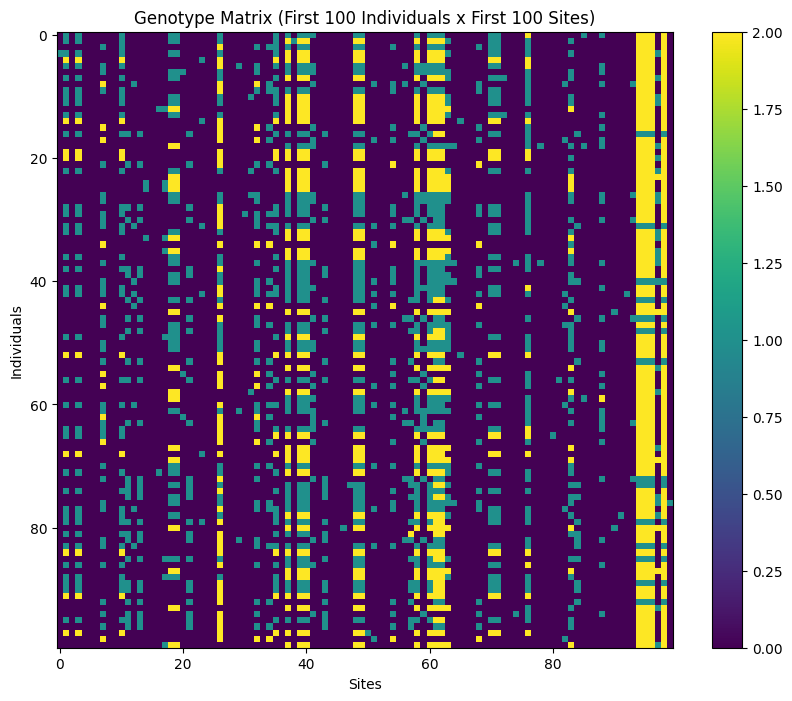

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(discovery_train_geno[:100, :100])
plt.colorbar()
plt.title("Genotype Matrix (First 100 Individuals x First 100 Sites)")
plt.xlabel("Sites")
plt.ylabel("Individuals")
plt.show()

## Understanding the effect of ancestry on the causal signal

In [65]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pickle

In [67]:
disc_train = np.load('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/genotype_matrices/discovery_train.npy')
target_held_out = np.load('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/genotype_matrices/target_held_out.npy')
with open('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/trait_df.pkl', 'rb') as f:
    trait_df = pickle.load(f)
biallelic_ids = np.load('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/biallelic_site_ids.npy')

/tmp/ipykernel_1683701/2974915239.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trait_df = pickle.load(f)


In [69]:
biallelic_ids

array([   12,    37,    38, ..., 23592, 23599, 23602], shape=(2622,))

In [70]:
trait_df

,position,site_id,effect_size,causal_allele,allele_freq,trait_id
0,8214,174,-1.039984,A,0.00025,0
1,23792,537,0.750451,T,0.00025,0
2,31497,728,0.940565,A,0.00800,0
3,35270,819,-1.951035,C,0.00025,0
4,37485,879,-1.302180,T,0.00275,0
...,...,...,...,...,...,...
195,983432,23143,0.643327,T,0.49100,0
196,991351,23380,-0.394605,C,0.00100,0
197,994874,23478,-0.005122,A,0.00075,0
198,999279,23592,-0.163443,A,0.00300,0


In [71]:
disc_train.shape

(784, 2622)

In [73]:
import numpy as np
import pandas as pd
import pickle

disc_train = np.load('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/genotype_matrices/discovery_train.npy')
target_held_out = np.load('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/genotype_matrices/target_held_out.npy')
with open('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/trait_df.pkl', 'rb') as f:
    trait_df = pickle.load(f)
biallelic_ids = np.load('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0/rep0/biallelic_site_ids.npy')

# Build a map from site_id -> column index in the genotype matrices
site_to_col = {site_id: col for col, site_id in enumerate(biallelic_ids)}

# Keep only causal SNPs that survived the MAF filter
causal_in_matrix = trait_df[trait_df.site_id.isin(site_to_col)].copy()

# Get column indices for each retained causal SNP
causal_in_matrix['col_idx'] = causal_in_matrix.site_id.map(site_to_col)

# Allele frequency = mean dosage / 2  (dosage is 0/1/2 copies of alt allele)
cols = causal_in_matrix.col_idx.values
causal_in_matrix['freq_disc_train']      = disc_train[:, cols].mean(axis=0) / 2
causal_in_matrix['freq_target_held_out'] = target_held_out[:, cols].mean(axis=0) / 2

# Variance contribution of SNP i: 2 * p * (1-p) * beta^2
def var_contribution(freq, effect):
    return 2 * freq * (1 - freq) * effect ** 2

causal_in_matrix['var_contrib_YRI_target_held_out'] = var_contribution(
    causal_in_matrix['freq_target_held_out'], causal_in_matrix['effect_size']
)
causal_in_matrix['var_contrib_CEU_disc_train'] = var_contribution(
    causal_in_matrix['freq_disc_train'], causal_in_matrix['effect_size']
)

# Assemble final table
table = causal_in_matrix[[
    'site_id',
    'freq_disc_train',
    'freq_target_held_out',
    'effect_size',
    'var_contrib_YRI_target_held_out',
    'var_contrib_CEU_disc_train',
]].rename(columns={
    'site_id':                       'causal_snp_id',
    'freq_disc_train':               'freq_CEU_disc_train',
    'freq_target_held_out':          'freq_YRI_target_held_out',
    'effect_size':                   'genetic_effect',
    'var_contrib_YRI_target_held_out': 'var_contrib_YRI',
    'var_contrib_CEU_disc_train':      'var_contrib_CEU',
}).reset_index(drop=True)

print(f"Causal SNPs surviving MAF filter: {len(table)} / {len(trait_df)}")

Causal SNPs surviving MAF filter: 19 / 200


/tmp/ipykernel_1683701/2234526644.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trait_df = pickle.load(f)


In [74]:
table

,causal_snp_id,freq_CEU_disc_train,freq_YRI_target_held_out,genetic_effect,var_contrib_YRI,var_contrib_CEU
0,3287,0.155612,0.000000,0.532309,0.000000,0.074464
1,3806,0.408163,0.361146,-0.406415,0.076217,0.079800
2,4452,0.005740,0.000000,-0.113947,0.000000,0.000148
3,5056,0.478316,0.503113,0.743254,0.276203,0.275694
4,7574,0.366071,0.483188,-0.275142,0.037809,0.035136
5,8003,0.568878,0.510585,-1.682870,1.415391,1.389154
6,8542,0.009566,0.000000,0.793347,0.000000,0.011927
7,11825,0.009566,0.000000,1.299228,0.000000,0.031987
8,11909,0.304209,0.133873,0.737516,0.126138,0.230263
9,14945,0.483418,0.210461,1.359188,0.613951,0.922680


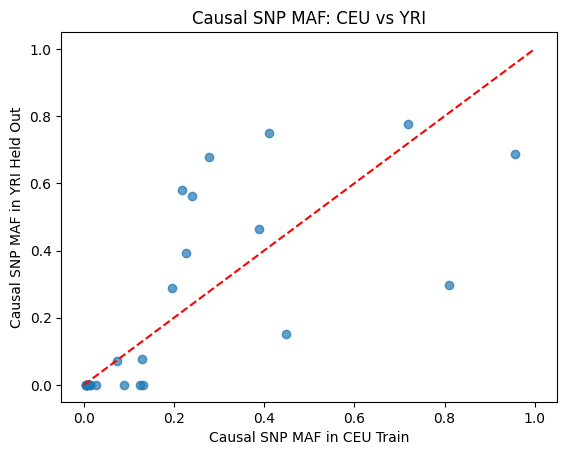

In [75]:
plt.figure()
plt.scatter(ceu_causal_freq, yri_causal_freq, alpha=0.7)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Causal SNP MAF in CEU Train')
plt.ylabel('Causal SNP MAF in YRI Held Out')
plt.title('Causal SNP MAF: CEU vs YRI')
plt.show()

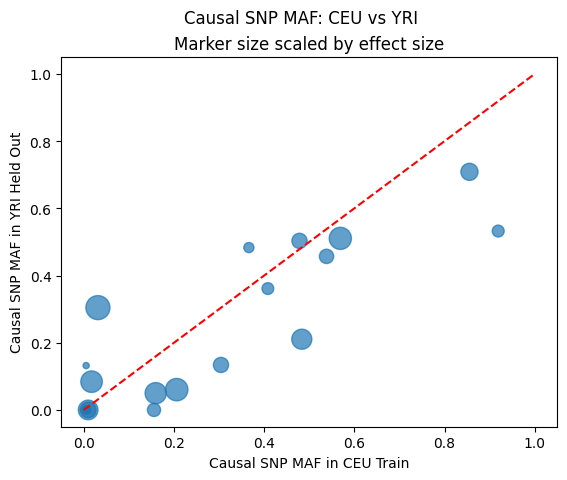

In [79]:
ceu_causal_freq  = table['freq_CEU_disc_train'].values
yri_causal_freq  = table['freq_YRI_target_held_out'].values
effect_abs       = np.abs(table['genetic_effect'].values)

marker_size = 20 + 280 * (effect_abs - effect_abs.min()) / (effect_abs.max() - effect_abs.min())

plt.figure()
plt.scatter(ceu_causal_freq, yri_causal_freq, s=marker_size, alpha=0.7)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Causal SNP MAF in CEU Train')
plt.ylabel('Causal SNP MAF in YRI Held Out')
plt.suptitle('Causal SNP MAF: CEU vs YRI')
plt.title(f'Marker size scaled by effect size')

plt.show()


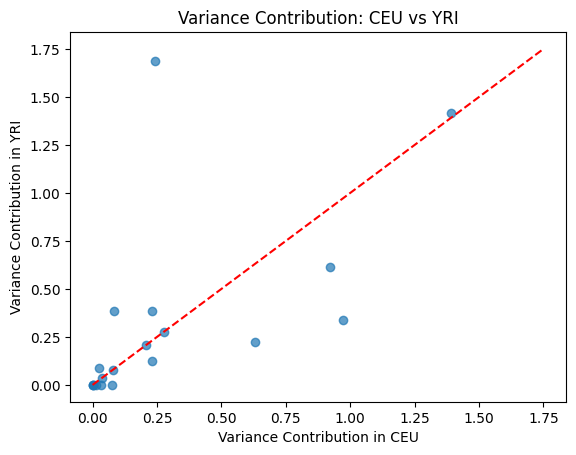

In [81]:
plt.figure()
plt.scatter(table['var_contrib_CEU'], table['var_contrib_YRI'], alpha=0.7)
plt.plot([0, 1.75], [0, 1.75], color='red', linestyle='--')
plt.xlabel('Variance Contribution in CEU')
plt.ylabel('Variance Contribution in YRI')
plt.title('Variance Contribution: CEU vs YRI')
plt.show()


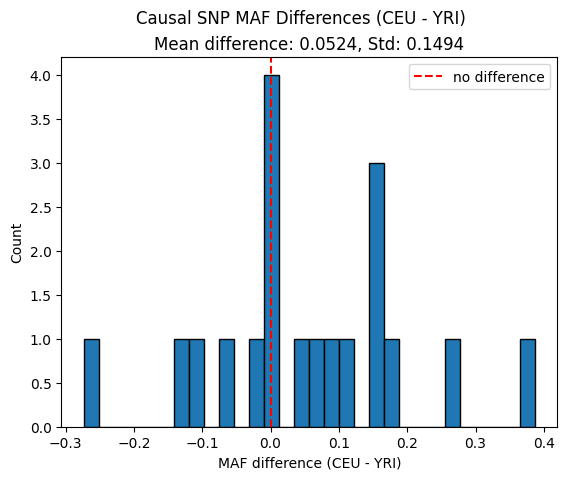

In [85]:
deviations = table['freq_CEU_disc_train'] - table['freq_YRI_target_held_out']
plt.figure()
plt.hist(deviations, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='no difference')
plt.xlabel('MAF difference (CEU - YRI)')
plt.ylabel('Count')
plt.suptitle('Causal SNP MAF Differences (CEU - YRI)')
plt.title(f'Mean difference: {deviations.mean():.4f}, Std: {deviations.std():.4f}')
plt.legend()
plt.show()

In [86]:
deviations

0     0.155612
1     0.047018
2     0.005740
3    -0.024797
4    -0.117117
5     0.058292
6     0.009566
7     0.009566
8     0.170336
9     0.272958
10   -0.273233
11    0.386627
12    0.146637
13   -0.126903
14   -0.066840
15    0.109626
16    0.145596
17    0.081229
18    0.005740
dtype: float32

/tmp/ipykernel_1052226/1428302210.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trait_df = pickle.load(f)
/tmp/ipykernel_1052226/1428302210.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the

rep0: 19/200 causal SNPs survive MAF filter
rep1: 21/200 causal SNPs survive MAF filter
rep2: 25/200 causal SNPs survive MAF filter
rep3: 29/200 causal SNPs survive MAF filter
rep4: 27/200 causal SNPs survive MAF filter


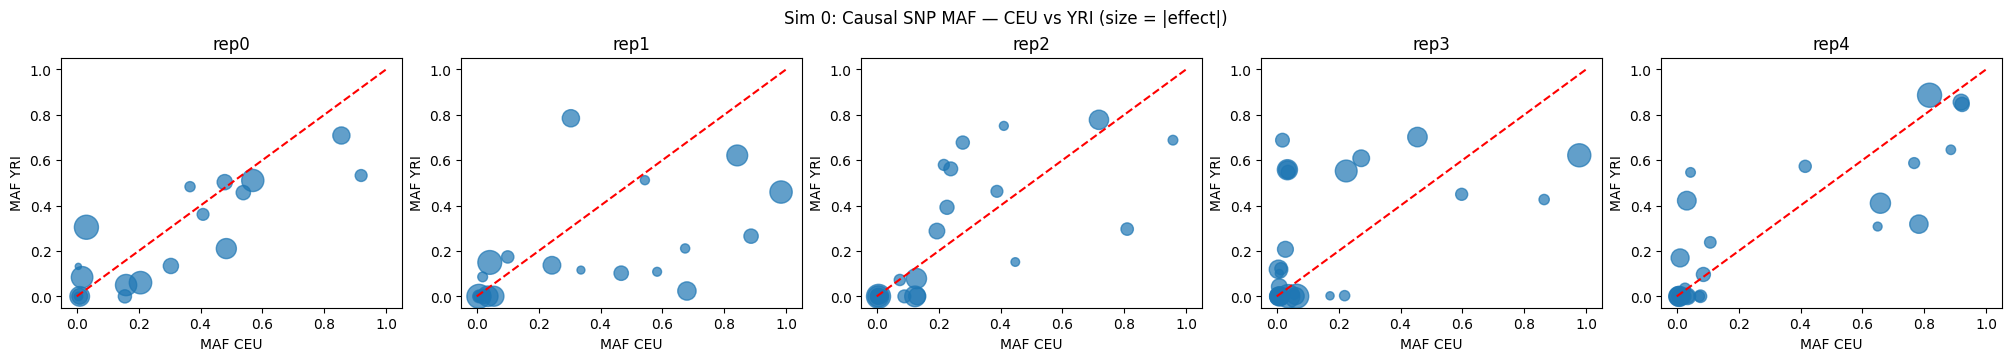

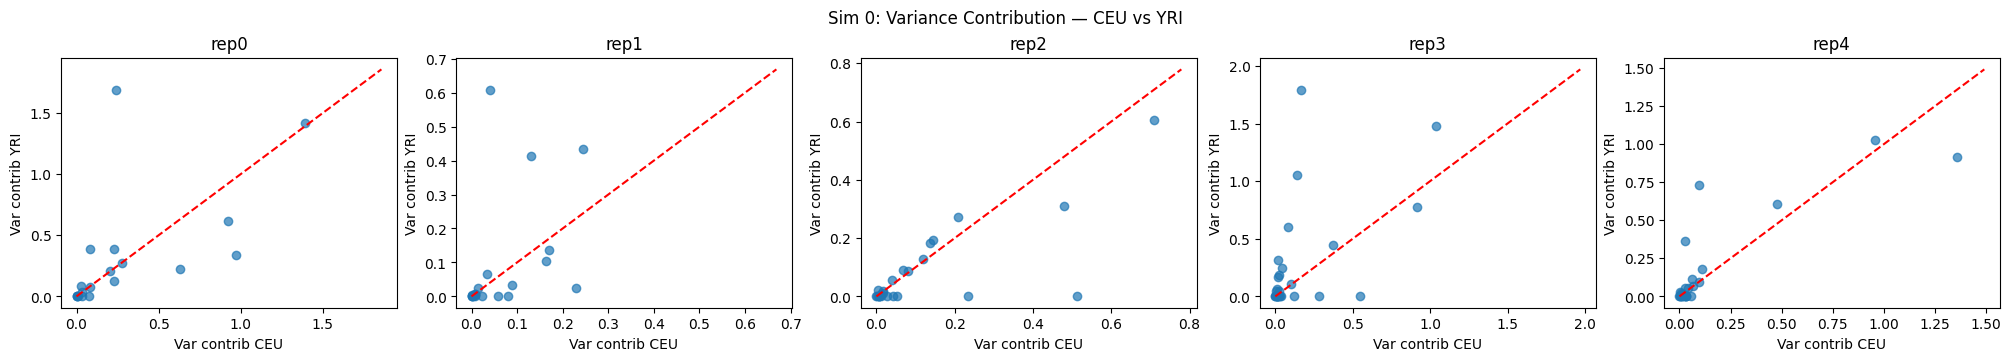

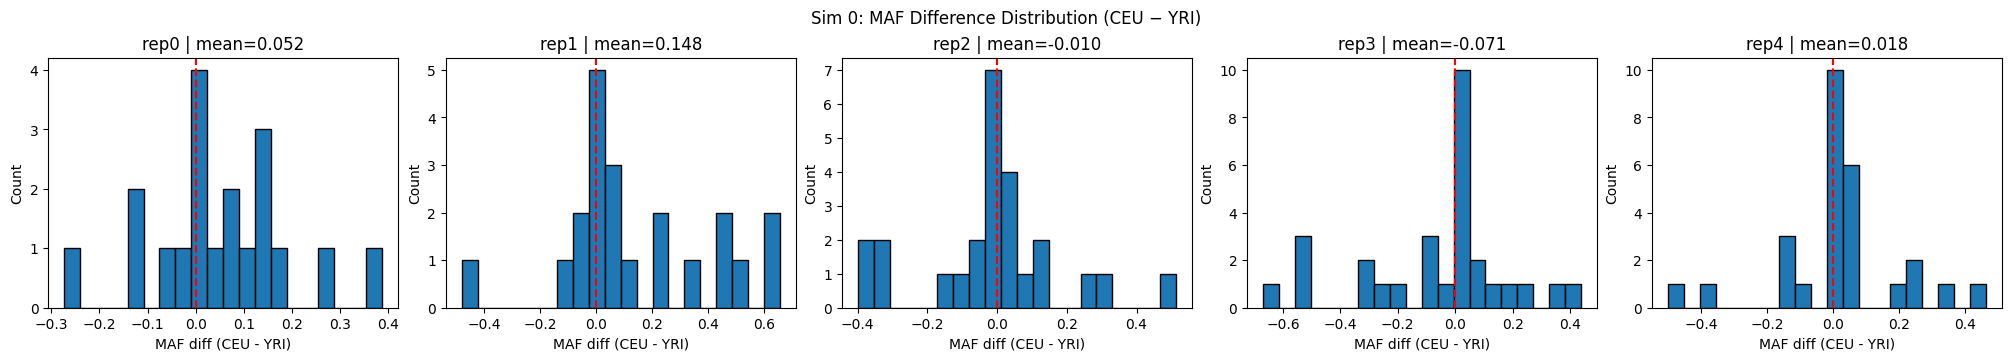


Rep          h2_CEU     h2_YRI  ratio (YRI/CEU)
------------------------------------------------
rep0         5.4435     5.8552           1.0756
rep1         1.3167     1.8677           1.4185
rep2         2.9357     1.9871           0.6769
rep3         4.0717     7.3454           1.8040
rep4         3.5909     4.2889           1.1944
------------------------------------------------
Mean                                     1.2339

Interpretation: a perfect CEU→YRI transfer model can explain at most
123.4% as much phenotypic variance in YRI as in CEU on average.


In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('/sietch_colab/akapoor/XPopVAE/experiments/OOA/processed_data/0')
SIM_ID = 0

def var_contribution(freq, effect):
    return 2 * freq * (1 - freq) * effect ** 2

def build_table(rep_dir):
    disc_train      = np.load(rep_dir / 'genotype_matrices/discovery_train.npy')
    target_held_out = np.load(rep_dir / 'genotype_matrices/target_held_out.npy')
    with open(rep_dir / 'trait_df.pkl', 'rb') as f:
        trait_df = pickle.load(f)
    biallelic_ids = np.load(rep_dir / 'biallelic_site_ids.npy')

    site_to_col = {site_id: col for col, site_id in enumerate(biallelic_ids)}
    causal = trait_df[trait_df.site_id.isin(site_to_col)].copy()
    causal['col_idx'] = causal.site_id.map(site_to_col)

    cols = causal.col_idx.values
    causal['freq_disc_train']      = disc_train[:, cols].mean(axis=0) / 2
    causal['freq_target_held_out'] = target_held_out[:, cols].mean(axis=0) / 2
    causal['var_contrib_YRI'] = var_contribution(causal['freq_target_held_out'], causal['effect_size'])
    causal['var_contrib_CEU'] = var_contribution(causal['freq_disc_train'],      causal['effect_size'])

    return causal[[
        'site_id', 'freq_disc_train', 'freq_target_held_out',
        'effect_size', 'var_contrib_YRI', 'var_contrib_CEU',
    ]].rename(columns={
        'site_id':              'causal_snp_id',
        'freq_disc_train':      'freq_CEU_disc_train',
        'freq_target_held_out': 'freq_YRI_target_held_out',
        'effect_size':          'genetic_effect',
    }).reset_index(drop=True), len(trait_df)


# --- dynamic grid sizing ---
rep_dirs = sorted(BASE.glob('rep*'), key=lambda p: int(p.name[3:]))
n_reps = len(rep_dirs)
ncols  = min(n_reps, 5)
nrows  = (n_reps + ncols - 1) // ncols
figsize = (4 * ncols, 3.5 * nrows)

fig_maf,  axes_maf  = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
fig_var,  axes_var  = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
fig_hist, axes_hist = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)

# hide all axes upfront; re-enable as we fill them
for fig in (fig_maf, fig_var, fig_hist):
    for ax in np.array(fig.axes).flat:
        ax.set_visible(False)

all_tables = {}

for ax_maf, ax_var, ax_hist, rep_dir in zip(
        np.array(fig_maf.axes).flat,
        np.array(fig_var.axes).flat,
        np.array(fig_hist.axes).flat,
        rep_dirs):

    for ax in (ax_maf, ax_var, ax_hist):
        ax.set_visible(True)

    rep_name = rep_dir.name
    table, n_causal_total = build_table(rep_dir)
    all_tables[rep_name] = table
    print(f"{rep_name}: {len(table)}/{n_causal_total} causal SNPs survive MAF filter")

    ceu = table['freq_CEU_disc_train'].values
    yri = table['freq_YRI_target_held_out'].values
    eff = np.abs(table['genetic_effect'].values)
    marker_size = 20 + 280 * (eff - eff.min()) / (eff.max() - eff.min() + 1e-9)

    # MAF scatter
    ax_maf.scatter(ceu, yri, s=marker_size, alpha=0.7)
    ax_maf.plot([0, 1], [0, 1], color='red', linestyle='--')
    ax_maf.set_xlabel('MAF CEU')
    ax_maf.set_ylabel('MAF YRI')
    ax_maf.set_title(rep_name)

    # Variance contribution scatter
    ax_var.scatter(table['var_contrib_CEU'], table['var_contrib_YRI'], alpha=0.7)
    lim = max(table['var_contrib_CEU'].max(), table['var_contrib_YRI'].max()) * 1.1
    ax_var.plot([0, lim], [0, lim], color='red', linestyle='--')
    ax_var.set_xlabel('Var contrib CEU')
    ax_var.set_ylabel('Var contrib YRI')
    ax_var.set_title(rep_name)

    # MAF difference histogram
    diff = ceu - yri
    ax_hist.hist(diff, bins=20, edgecolor='black')
    ax_hist.axvline(0, color='red', linestyle='--')
    ax_hist.set_xlabel('MAF diff (CEU - YRI)')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f"{rep_name} | mean={diff.mean():.3f}")

fig_maf.suptitle(f'Sim {SIM_ID}: Causal SNP MAF — CEU vs YRI (size = |effect|)')
fig_var.suptitle(f'Sim {SIM_ID}: Variance Contribution — CEU vs YRI')
fig_hist.suptitle(f'Sim {SIM_ID}: MAF Difference Distribution (CEU − YRI)')

plt.show()

# Heritability ratios
print(f"\n{'Rep':<8} {'h2_CEU':>10} {'h2_YRI':>10} {'ratio (YRI/CEU)':>16}")
print("-" * 48)

ratios = {}
for rep_name, table in sorted(all_tables.items()):
    h2_ceu = table['var_contrib_CEU'].sum()
    h2_yri = table['var_contrib_YRI'].sum()
    ratio  = h2_yri / h2_ceu
    ratios[rep_name] = ratio
    print(f"{rep_name:<8} {h2_ceu:>10.4f} {h2_yri:>10.4f} {ratio:>16.4f}")

mean_ratio = np.mean(list(ratios.values()))
print("-" * 48)
print(f"{'Mean':<8} {'':>10} {'':>10} {mean_ratio:>16.4f}")
print(f"\nInterpretation: a perfect CEU→YRI transfer model can explain at most")
print(f"{mean_ratio:.1%} as much phenotypic variance in YRI as in CEU on average.")